# Deutsch-Josza algorithm

#### Problem: find whether the Boolean function $f(x):\{0,1\}^n\rightarrow\{0,1\}$ is constant or balanced 

### Import section

In [1]:
from qiskit import *
from qiskit.visualization import plot_histogram
from qiskit_ibm_runtime import *
import numpy as np
from math import pi

from qiskit_aer import StatevectorSimulator, QasmSimulator, UnitarySimulator

### 1. Set length of first register and oracle

In [8]:
n = 4

# set the oracle: b for balanced, c for constant
oracle = "b"

# if the oracle is balanced, set the hidden bitstring, b
if oracle == "b":
    b = np.random.randint(1,2**n) # you can choose  the number 
    display(b)
# if the oracle is constant, set c = 0 or 1 randomly.
if oracle == "c":
    c = np.random.randint(2)
    display(c)
    

2

### 2. Initialize first register in $|+\rangle^{\otimes n}$, second register (1 qubit) in $|-\rangle$ 

In [9]:
qc = QuantumCircuit(n+1,n)
qc.x(n)

# Apply Hadamard gates to all qubits
qc.h(range(n+1))

qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=5, num_clbits=0, params=[]), qubits=(<Qubit register=(5, "q"), index=0>, <Qubit register=(5, "q"), index=1>, <Qubit register=(5, "q"), index=2>, <Qubit register=(5, "q"), index=3>, <Qubit register=(5, "q"), index=4>), clbits=())

### 3. Construct oracle function 

In [10]:
if oracle == "c":
    if c == 1:
        qc.x(n)
    else:
        qc.id(n)
else:
    # the random number b tells us which CNOTs to wrap in X-gates:
    
    # Next, format 'b' as a binary string of length 'n', padded with zeros:
    b_str = format(b, '0'+str(n)+'b')
    # Next, we place the first X-gates. Each digit in our binary string 
    # corresponds to a qubit, if the digit is 0, we do nothing, if it's 1 we apply an X-gate to that qubit:
    for qubit in range(len(b_str)):
        if b_str[qubit] == '1':
            qc.x(qubit)
    # Do the controlled-NOT gates for each qubit, using the output qubit as the target:
    for qubit in range(n):
        qc.cx(qubit, n)
    # Next, place the final X-gates
    for qubit in range(len(b_str)):
        if b_str[qubit] == '1':
            qc.x(qubit)
            
qc.barrier()            

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=5, num_clbits=0, params=[]), qubits=(<Qubit register=(5, "q"), index=0>, <Qubit register=(5, "q"), index=1>, <Qubit register=(5, "q"), index=2>, <Qubit register=(5, "q"), index=3>, <Qubit register=(5, "q"), index=4>), clbits=())

In [11]:
b_str

'0010'

### 3. Measure in X-basis the first register

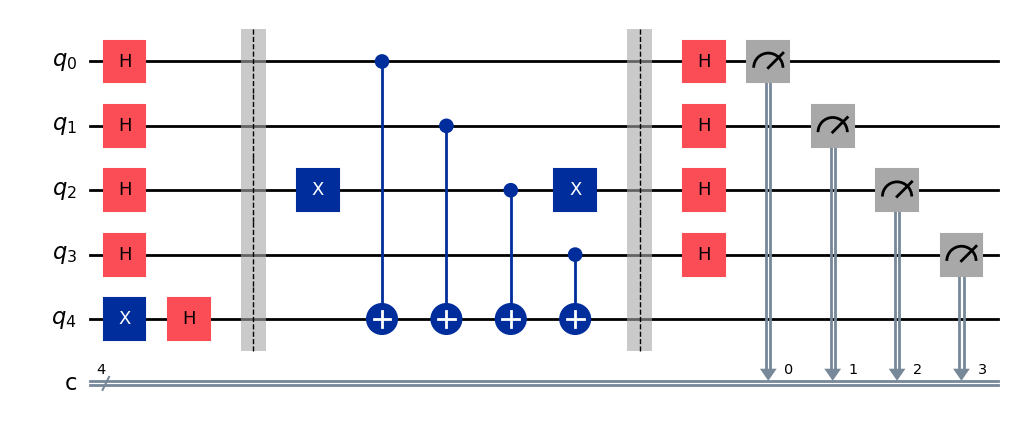

In [12]:
# apply Hadamard gates to the first register
qc.h(range(n))  
qc.measure(range(n),range(n))

qc.draw('mpl')

{'1111': 1}


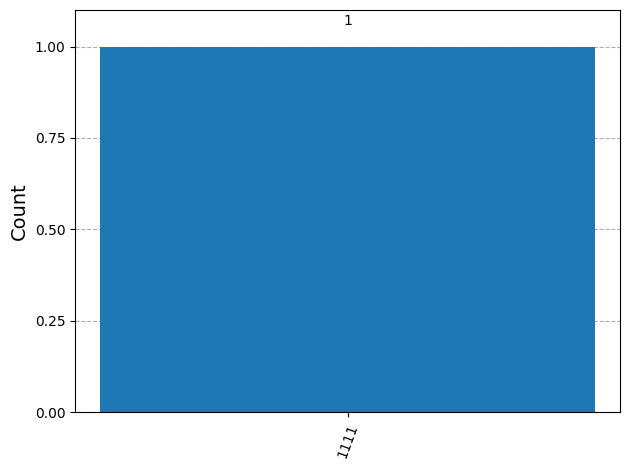

In [13]:
# use local simulator
backend = QasmSimulator()
counts = backend.run(qc,shots = 1).result().get_counts()
print(counts)
plot_histogram(counts)

## Run on real hardware

In [10]:
# Qiskit Runtime imports
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import EstimatorV2 as Estimator

# Sostituisci 'IL_TUO_API_TOKEN' con il token reale copiato dalla dashboard
QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform", 
    token="wfEHJFGlur25cWBX4fdE0468cOfFfVxSVSlubtbf_00e", 
    overwrite=True, 
    set_as_default=True
)

# To run on hardware, select the backend with the fewest number of jobs in the queue
service = QiskitRuntimeService()
backend = service.least_busy(
    operational=True, simulator=False, min_num_qubits=127
)
backend.name

qiskit_runtime_service.__init__:WARNING:2026-03-17 15:49:22,273: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-03-17 15:49:23,001: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-03-17 15:49:26,896: Using instance: open-instance, plan: open


'ibm_fez'

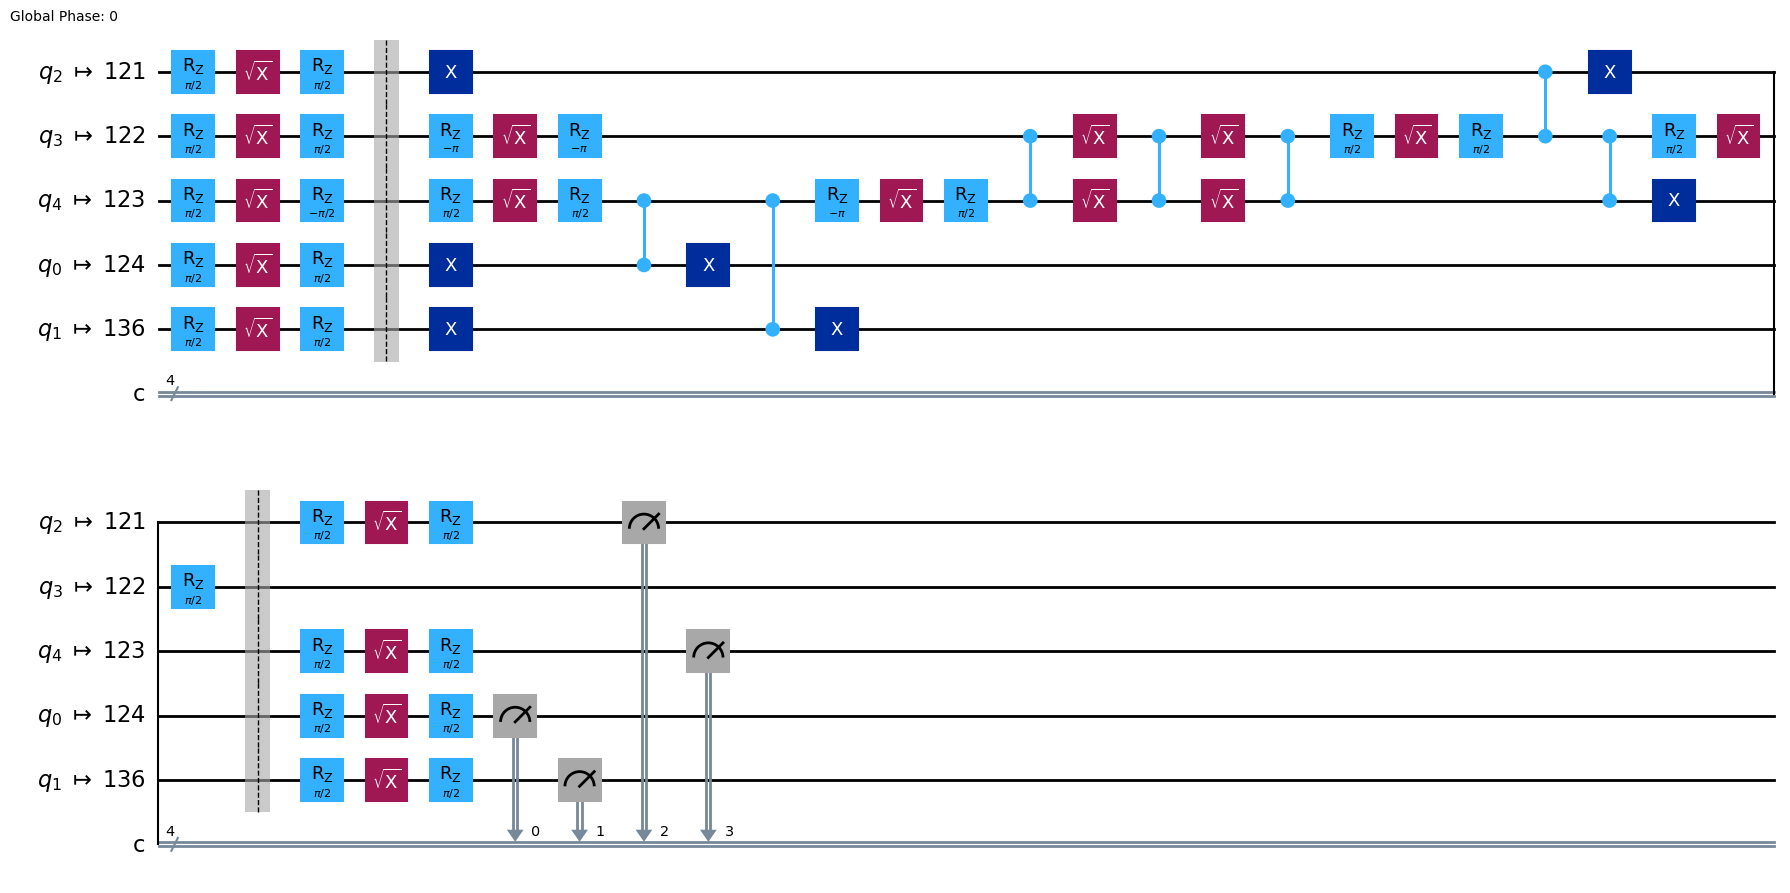

gates =  OrderedDict([('rz', 28), ('sx', 18), ('x', 7), ('cz', 7), ('measure', 4), ('barrier', 2)])
depth =  28


In [11]:
from qiskit.visualization import plot_circuit_layout

new_circ_lv1 = transpile(qc, backend=backend, optimization_level=1)
#display(plot_circuit_layout(new_circ_lv0, backend))

display(new_circ_lv1.draw('mpl'))
print('gates = ', new_circ_lv1.count_ops())
print('depth = ', new_circ_lv1.depth())

In [15]:

job = backend.run(new_circ_lv1,shots = 1024)


IBMBackendError: 'Support for backend.run() has been removed. Please see our migration guide https://quantum.cloud.ibm.com/docs/migration-guides/qiskit-runtime for instructions on how to migrate to the primitives interface.'

In [19]:
# check job status
job.status()

<JobStatus.QUEUED: 'job is queued'>

In [ ]:
counts = job.result().get_counts()
print(counts)
plot_histogram(counts)
print(counts)